In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt



2025-05-19 01:02:59.854308: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load your trained flood model
flood_model = load_model("/home/ronny/rada-project/models/lstm_flood_model.keras")  # Change filename as needed

# Load the new dataset (from another county)
df = pd.read_csv("/home/ronny/rada-project/weather-data-csv/kisii-data.csv")

# Ensure data is sorted chronologically (important for rolling calculations)
# df = df.sort_values(by="time")  # If there's a 'date' column



In [3]:
# Compute the same derived and normalized columns used in training
df['3_day_cum_precip'] = df['precipitation'].rolling(window=3).sum()
df['norm_precip'] = df['3_day_cum_precip'] / df['3_day_cum_precip'].max()
df['norm_humidity'] = df['humidity'] / df['humidity'].max()
df['norm_dew_point'] = df['dew_point'] / df['dew_point'].max()
df['norm_pressure'] = 1 - (df['pressure'] / df['pressure'].max())  # Inverted

# Compute the target flood probability
df['flood_probability'] = (
    (df['norm_precip'] * 0.5) +
    (df['norm_humidity'] * 0.2) +
    (df['norm_dew_point'] * 0.2) +
    (df['norm_pressure'] * 0.1)
).clip(0, 1)



In [4]:
# Drop NaN rows caused by rolling window
df = df.dropna()

# Use same feature columns as training
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
X = df[features].values
y_true = df['flood_probability'].values



In [5]:
# Reshape for LSTM input: (samples, timesteps, features)
# Assume your model was trained with a window size (e.g., 10 time steps)
def create_sequences(data, labels, seq_len=20):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(data)):
        X_seq.append(data[i-seq_len:i])
        y_seq.append(labels[i])
    return np.array(X_seq), np.array(y_seq)

seq_length = 20
X_seq, y_seq = create_sequences(X, y_true, seq_length)



In [6]:
# Make predictions
y_pred = flood_model.predict(X_seq).flatten()

# Evaluation
mae = mean_absolute_error(y_seq, y_pred)
rmse = np.sqrt(mean_squared_error(y_seq, y_pred))
r2 = r2_score(y_seq, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
MAE: 0.2045
RMSE: 0.2127
R² Score: -4.4778


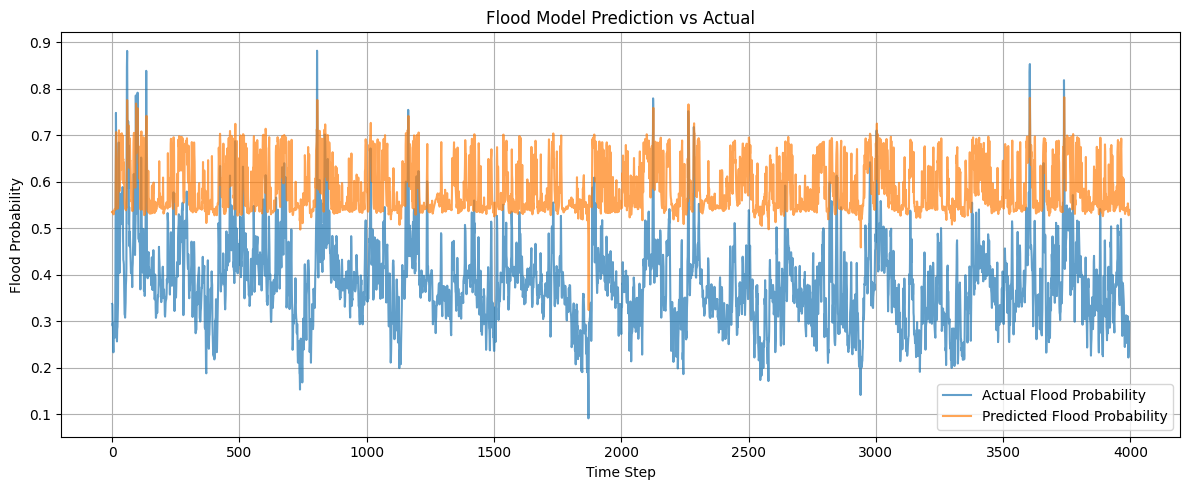

In [8]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_seq, label="Actual Flood Probability", alpha=0.7)
plt.plot(y_pred, label="Predicted Flood Probability", alpha=0.7)
plt.title("Flood Model Prediction vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Flood Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

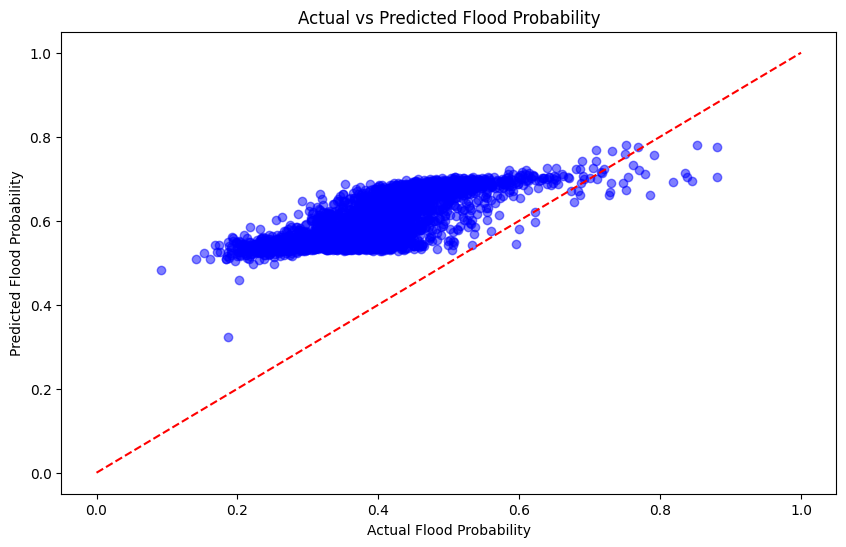

In [9]:
# 🔹 Plot Actual vs Predicted for ALL DATA
plt.figure(figsize=(10, 6))
plt.scatter(y_seq, y_pred, alpha=0.5, color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Perfect prediction line
plt.xlabel("Actual Flood Probability")
plt.ylabel("Predicted Flood Probability")
plt.title("Actual vs Predicted Flood Probability")
plt.show()